<a href="https://colab.research.google.com/github/mahathi-kannan/CodeAlpha_Unemployment_Analysis/blob/main/unemployment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Cleaned Data Overview ---
Total Records: 740 rows
           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  Year  \
0          11999139.0                                    43.24  Rural  2019   
1          11755881.0                                    42.05  Rural  2019   
2          12086707.0                                    43.50  Rural  2019   
3          12285693.0                                    43.97  Rural  2019   
4          12256762.0                                    44.68  Rural  2019   

       Month  
0    

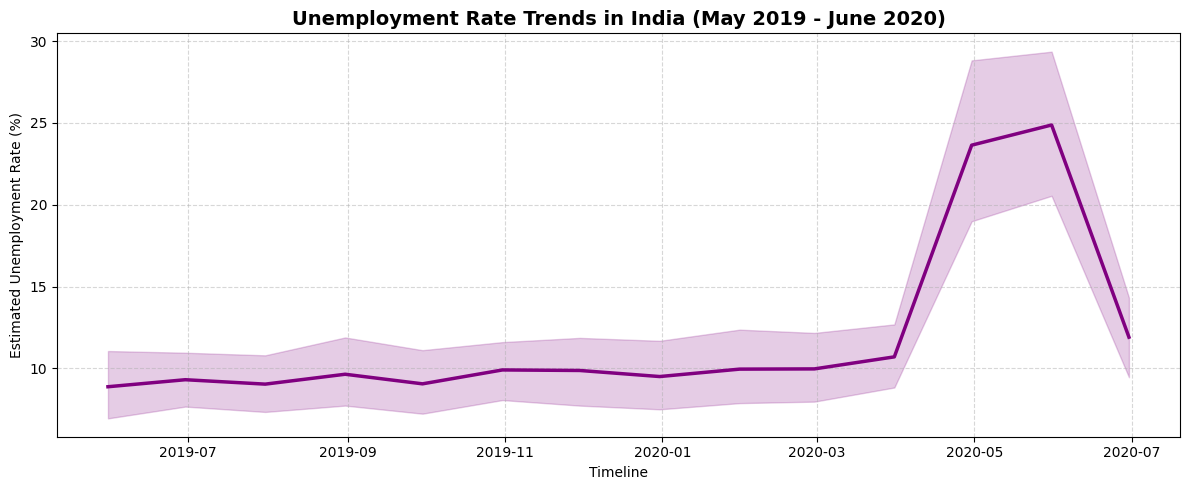


Analyzing the COVID-19 lockdown impact...


/tmp/ipykernel_2218/892652532.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2020, x='Month', y='Estimated Unemployment Rate (%)', order=month_order, palette='flare', errorbar=None)


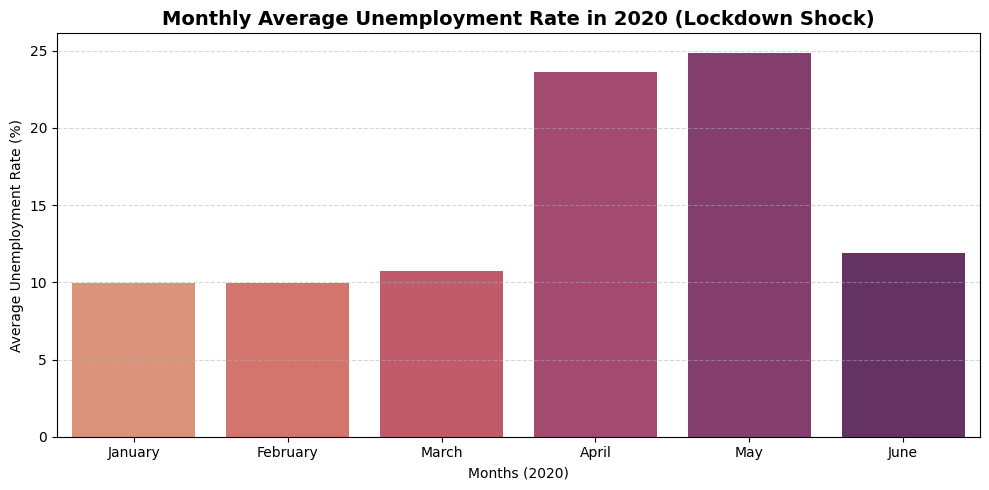

/tmp/ipykernel_2218/892652532.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='pastel')


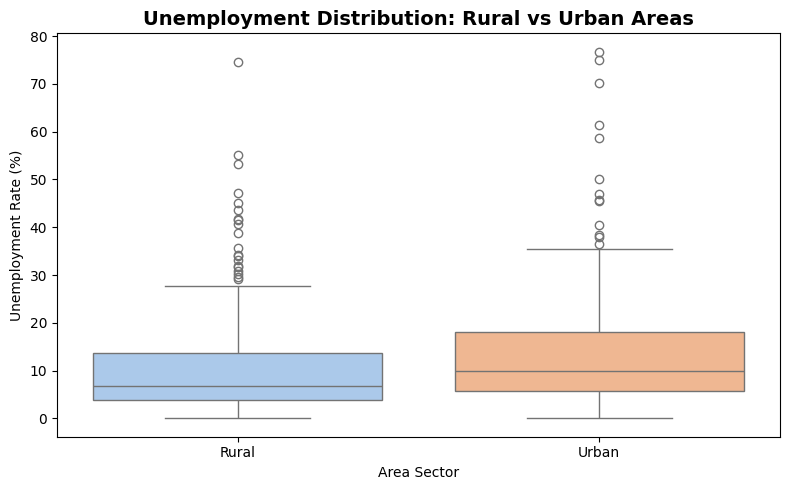


Top 5 Regions with highest average unemployment during peak lockdown (April-May 2020):
Region
Puducherry    75.416667
Jharkhand     57.117500
Bihar         47.247500
Tamil Nadu    40.855000
Haryana       40.295000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# (Make sure 'Unemployment in India.csv' is uploaded to your Colab session)
df = pd.read_csv('Unemployment in India.csv')

# 2. Data Cleaning
# Strip unexpected spaces from the column names
df.columns = df.columns.str.strip()

# Drop completely null placeholder rows (if any) to clean the dataset
df = df.dropna(subset=['Date', 'Estimated Unemployment Rate (%)'])

# Convert Date to datetime format and extract Time dimensions
df['Date'] = pd.to_datetime(df['Date'].str.strip(), dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

print("--- Cleaned Data Overview ---")
print(f"Total Records: {df.shape[0]} rows")
print(df.head())

# 3. Overall Timeline Analysis (Line Plot)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', color='purple', linewidth=2.5)
plt.title('Unemployment Rate Trends in India (May 2019 - June 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Investigating COVID-19 Shock (Focusing on 2020 Months)
print("\nAnalyzing the COVID-19 lockdown impact...")
df_2020 = df[df['Year'] == 2020]
month_order = ['January', 'February', 'March', 'April', 'May', 'June']

plt.figure(figsize=(10, 5))
sns.barplot(data=df_2020, x='Month', y='Estimated Unemployment Rate (%)', order=month_order, palette='flare', errorbar=None)
plt.title('Monthly Average Unemployment Rate in 2020 (Lockdown Shock)', fontsize=14, fontweight='bold')
plt.xlabel('Months (2020)')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Segment Analysis: Rural vs Urban Comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='pastel')
plt.title('Unemployment Distribution: Rural vs Urban Areas', fontsize=14, fontweight='bold')
plt.xlabel('Area Sector')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# 6. Top Affected Regions (States) during the peak of lockdown (April - May 2020)
print("\nTop 5 Regions with highest average unemployment during peak lockdown (April-May 2020):")
lockdown_peak = df_2020[df_2020['Month'].isin(['April', 'May'])]
top_regions = lockdown_peak.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(5)
print(top_regions.to_string())